In [1]:
from train_classifier import CustomImageDataset
from torchvision import transforms
transform = transforms.Compose([
        transforms.Resize((224, 224)),  # EfficientNet expects 224x224
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet normalization
                             std=[0.229, 0.224, 0.225])
    ])
ds = CustomImageDataset("dataset-Br35H/TRAIN", transform=transform)

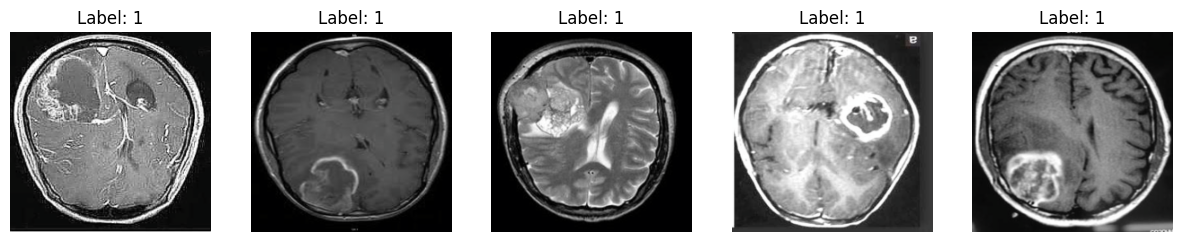

In [4]:
#get n random samples from the dataset and plot images with labels
import matplotlib.pyplot as plt
import random
import numpy as np
n = 5
samples = random.sample(range(len(ds)), n)
fig, axs = plt.subplots(1, n, figsize=(15, 5))
for i, idx in enumerate(samples):
    img, label = ds[idx]
    img = img.permute(1, 2, 0).numpy()  # Convert from CxHxW to HxWxC
    img = (img * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]  # Unnormalize
    img = np.clip(img, 0, 1)  # Clip to valid range
    axs[i].imshow(img)
    axs[i].set_title(f"Label: {label}")
    axs[i].axis('off')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Text(0.5, 1.0, '  Transformed Image')

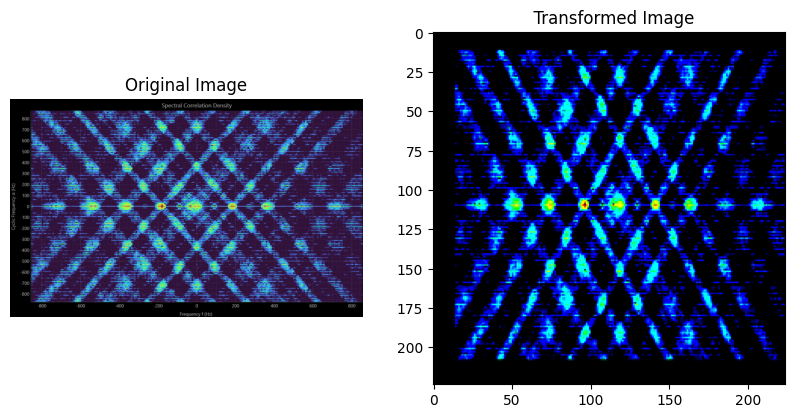

In [3]:
og_image = 'image.png'
# transform the image
from PIL import Image
img = Image.open(og_image)
img = transform(img)
#plot both sides by side
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
# original image
axs[0].imshow(Image.open(og_image))
axs[0].set_title('Original Image')
axs[0].axis('off')
# transformed image
axs[1].imshow(img.permute(1, 2, 0))  # permute to (H, W, C) for plotting
axs[1].set_title('  Transformed Image') 

In [ ]:
# plot 10 images
import matplotlib.pyplot as plt
for i in range(10):
        
    img, label = ds[i]
    plt.imshow(img.permute(1, 2, 0))
    plt.title(label)
    plt.show()

    print(f'label: {label}')